# NB07 — Metabolite categorical view (ChEBI)

**Bonus analysis**: Use the 4,367 ChEBI metabolite identifications across 22 Harvard Forest samples to ask:
1. Are some metabolites preferentially detected in heated vs control samples?
2. Does the *number* of identified metabolites per sample differ between heated and control?

Note: this is **presence/absence + similarity score**, not quantitative abundance — `nmdc_arkin.metabolomics_gold` would have peak areas but is excluded from this project. So all tests are categorical.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact, mannwhitneyu, false_discovery_control

DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')

design = pd.read_csv(os.path.join(DATA_DIR, 'sample_design.tsv'), sep='\t')
met = pd.read_csv(os.path.join(DATA_DIR, 'metabolite_ids_by_sample.tsv.gz'), sep='\t')
print(f'Metabolite IDs: {len(met):,}')
print(f'Samples with metabolites: {met["biosample_id"].nunique()}')
print(f'Distinct ChEBI: {met["chebi_id"].nunique():,}')

design_idx = design.set_index('biosample_id')
samples = sorted(met['biosample_id'].unique())
meta_sub = design_idx.loc[samples, ['sample_name', 'treatment', 'horizon', 'incubated', 'plot']]
print('\nSample design:')
print(meta_sub.groupby(['treatment', 'horizon']).size())

Metabolite IDs: 4,367
Samples with metabolites: 22
Distinct ChEBI: 319

Sample design:
treatment  horizon
control    mineral    6
           organic    5
heated     mineral    6
           organic    5
dtype: int64


## 1. Per-sample metabolite count

Number of distinct ChEBI IDs per sample, grouped by treatment × horizon.

In [2]:
n_per_sample = met.groupby('biosample_id')['chebi_id'].nunique().rename('n_distinct_chebi')
stats_df = meta_sub.join(n_per_sample)
print('Distinct ChEBI counts per sample:')
print(stats_df.groupby(['treatment', 'horizon'])['n_distinct_chebi'].agg(['count', 'mean', 'std', 'min', 'max']))

# Mann-Whitney U: heated vs control
for hz in ['organic', 'mineral']:
    sub = stats_df[stats_df['horizon'] == hz]
    c = sub.loc[sub['treatment'] == 'control', 'n_distinct_chebi'].values
    h = sub.loc[sub['treatment'] == 'heated', 'n_distinct_chebi'].values
    if len(c) >= 3 and len(h) >= 3:
        u, p = mannwhitneyu(h, c, alternative='two-sided')
        print(f'\n{hz}: control mean={c.mean():.0f} (n={len(c)}); heated mean={h.mean():.0f} (n={len(h)}); MW p={p:.3f}')

Distinct ChEBI counts per sample:
                   count        mean        std  min  max
treatment horizon                                        
control   mineral      6  166.833333   9.368387  158  181
          organic      5  172.800000   6.260990  167  183
heated    mineral      6  155.333333   3.829708  149  160
          organic      5  159.800000  13.311649  146  173

organic: control mean=173 (n=5); heated mean=160 (n=5); MW p=0.209

mineral: control mean=167 (n=6); heated mean=155 (n=6); MW p=0.012


## 2. Build the sample × ChEBI presence matrix

In [3]:
# Use unique sample x chebi (collapse duplicates)
presence = (met.groupby(['biosample_id', 'chebi_id']).size().unstack(fill_value=0) > 0).astype(int)
presence = presence.reindex(samples, fill_value=0)
print(f'Presence matrix: {presence.shape}')
print(f'Sample-level metabolite richness (mean): {presence.sum(axis=1).mean():.0f}')

Presence matrix: (22, 319)
Sample-level metabolite richness (mean): 163


## 3. Per-ChEBI Fisher's exact test (heated vs control)

In [4]:
treatments = meta_sub['treatment']
ctrl_idx = treatments[treatments == 'control'].index
heat_idx = treatments[treatments == 'heated'].index
n_ctrl = len(ctrl_idx)
n_heat = len(heat_idx)
print(f'Control samples: {n_ctrl}; Heated samples: {n_heat}')

# Filter to ChEBI present in at least 3 samples and missing from at least 3 samples
n_pos = presence.sum(axis=0)
tested = n_pos[(n_pos >= 3) & (n_pos <= n_ctrl + n_heat - 3)].index
print(f'Testable ChEBI (3-{n_ctrl+n_heat-3} positive samples): {len(tested):,}')

rows = []
for chebi in tested:
    col = presence[chebi]
    a = int(col.loc[heat_idx].sum())   # heated +
    b = int(col.loc[ctrl_idx].sum())   # control +
    c_n = n_heat - a                   # heated -
    d   = n_ctrl - b                   # control -
    OR, p = fisher_exact([[a, b], [c_n, d]], alternative='two-sided')
    log2_or = np.log2(OR + 1e-9) if (OR > 0 and not np.isinf(OR)) else np.sign(OR) * 10
    rows.append({'chebi_id': chebi, 'heated_pos': a, 'control_pos': b,
                  'heated_n': n_heat, 'control_n': n_ctrl,
                  'OR': OR, 'log2_OR': log2_or, 'p': p})
fisher = pd.DataFrame(rows)
fisher['q'] = false_discovery_control(fisher['p'].values, method='bh')
fisher = fisher.sort_values('p')
print(f'\nTop 20 differential ChEBI hits:')
print(fisher.head(20).to_string(index=False))

Control samples: 11; Heated samples: 11
Testable ChEBI (3-19 positive samples): 172



Top 20 differential ChEBI hits:
    chebi_id  heated_pos  control_pos  heated_n  control_n        OR   log2_OR        p        q
 chebi:30918           0            6        11         11  0.000000  0.000000 0.012384 0.912870
 chebi:15729           0            5        11         11  0.000000  0.000000 0.035088 0.912870
 chebi:57543           0            5        11         11  0.000000  0.000000 0.035088 0.912870
 chebi:58359           6           11        11         11  0.000000  0.000000 0.035088 0.912870
 chebi:71028          11            6        11         11       inf 10.000000 0.035088 0.912870
 chebi:81298           0            5        11         11  0.000000  0.000000 0.035088 0.912870
 chebi:28130           5           10        11         11  0.083333 -3.584962 0.063467 0.912870
 chebi:27967          10            5        11         11 12.000000  3.584963 0.063467 0.912870
 chebi:19543           1            6        11         11  0.083333 -3.584962 0.063467 0.9128

## 4. ChEBI category aggregation

Aggregate ChEBI IDs by parsing the prefix and ID number, but without an ontology lookup we can only do simple counts. Save the differential hits for downstream interpretation.

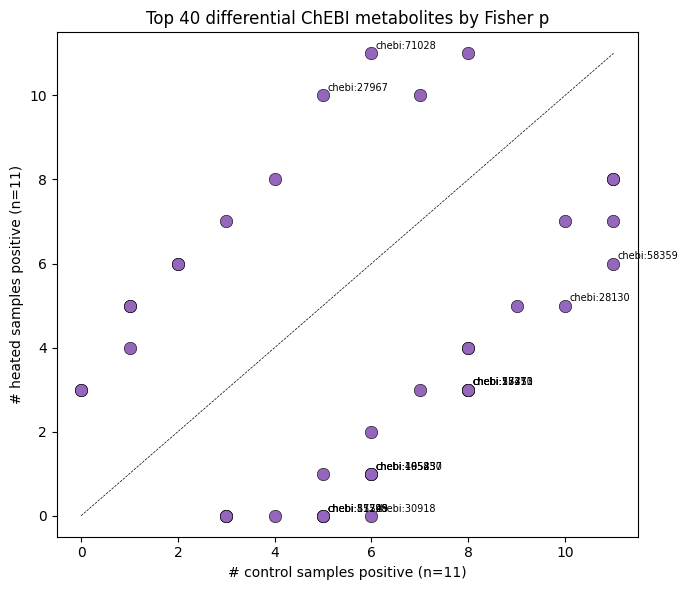

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/07_metabolite_scatter.png


In [5]:
# Plot: heated_pos vs control_pos for top metabolites
top = fisher.head(40)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(top['control_pos'], top['heated_pos'], s=80, color='#9467bd', edgecolors='black', linewidths=0.4)
for _, r in top.head(15).iterrows():
    ax.annotate(r['chebi_id'], (r['control_pos'], r['heated_pos']), fontsize=7,
                xytext=(3, 3), textcoords='offset points')
ax.plot([0, max(n_ctrl, n_heat)], [0, max(n_ctrl, n_heat)], 'k--', linewidth=0.5)
ax.set_xlabel(f'# control samples positive (n={n_ctrl})')
ax.set_ylabel(f'# heated samples positive (n={n_heat})')
ax.set_title(f'Top 40 differential ChEBI metabolites by Fisher p')
ax.set_xlim(-0.5, n_ctrl + 0.5); ax.set_ylim(-0.5, n_heat + 0.5)
plt.tight_layout()
out = os.path.join(FIG_DIR, '07_metabolite_scatter.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 5. Heatmap of top differential ChEBIs across samples

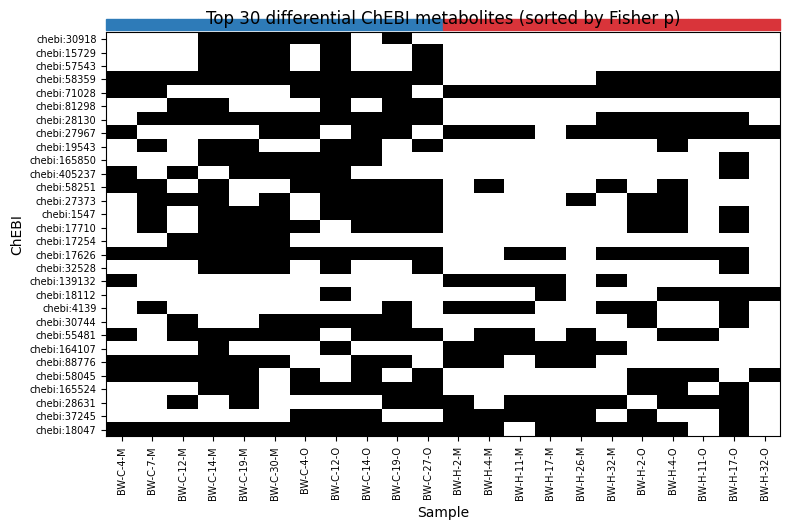

Wrote /home/cmungall/BERIL-research-observatory/projects/harvard_forest_warming/figures/07_metabolite_heatmap.png


In [6]:
top_kos = fisher.head(30)['chebi_id'].tolist()
M = presence[top_kos]
ordered = meta_sub.sort_values(['treatment', 'horizon', 'plot']).index
M = M.loc[ordered]

fig, ax = plt.subplots(figsize=(8, max(4, len(top_kos) * 0.18)))
ax.imshow(M.values.T, aspect='auto', cmap='Greys', vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks(range(len(ordered)))
ax.set_xticklabels([f"{meta_sub.loc[s, 'sample_name']}" for s in ordered], rotation=90, fontsize=7)
ax.set_yticks(range(len(top_kos)))
ax.set_yticklabels(top_kos, fontsize=7)
ax.set_xlabel('Sample')
ax.set_ylabel('ChEBI')
ax.set_title(f'Top 30 differential ChEBI metabolites (sorted by Fisher p)')
# Color bar at top for treatment
tcolors = meta_sub.loc[ordered, 'treatment'].map({'control': '#2e7bb8', 'heated': '#d9343a'})
for i, c in enumerate(tcolors):
    ax.add_patch(plt.Rectangle((i - 0.5, -1.5), 1.0, 0.8, color=c, clip_on=False))
plt.tight_layout()
out = os.path.join(FIG_DIR, '07_metabolite_heatmap.png')
plt.savefig(out, dpi=150)
plt.show()
print(f'Wrote {out}')

## 6. Save outputs

In [7]:
fisher.to_csv(os.path.join(DATA_DIR, '07_chebi_fisher.tsv'), sep='\t', index=False)
stats_df.to_csv(os.path.join(DATA_DIR, '07_chebi_count_per_sample.tsv'), sep='\t')
presence.to_csv(os.path.join(DATA_DIR, '07_chebi_presence.tsv.gz'), sep='\t', compression='gzip')
print('Saved 3 outputs.')

Saved 3 outputs.


## 7. Summary

1. Per-sample metabolite richness comparison (heated vs control) by horizon.
2. Per-ChEBI Fisher's exact test highlights metabolites preferentially detected in heated or control samples.
3. Heatmap shows top differential ChEBI presence pattern across the 22 metabolomics samples.
4. ChEBI IDs are returned as raw `chebi:XXXXX` strings — looking them up in OLS is left as a follow-up since this project does not have an in-lakehouse ChEBI hierarchy.